In [ ]:
# Update location of images to run cells in this notebook

# Location of data that has been pre-split into train, validation and test (holdout) sets with data augmentation for all anomaly images
# These datasets can be generated for a chosen object type using the notebook '2.2-suzy-data-augmentation.ipynb'
split_aug_data = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_multi_class/split_val_test_before_augmentation'


In [1]:
# Library imports

from pathlib import Path
import os
import cv2
import numpy as np
import pandas as pd

# Imports for visualizations
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Imports for ML
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.metrics import classification_report_imbalanced


In [2]:
# Imports for CNNs

# Imports for building the model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import LeakyReLU
# Imports for model training
from tensorflow.keras.callbacks import EarlyStopping

# Imports for image transformations
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomContrast 
from tensorflow.keras.layers import RandomTranslation

# Importing the image_dataset_from_directory utility from Keras
from keras.utils import image_dataset_from_directory

# Importing loss function
from tensorflow.keras.losses import CategoricalCrossentropy


/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
# Functions

def plot_training(model_history):
    train_loss = model_history.history["loss"]
    val_loss = model_history.history["val_loss"]
    
    train_acc = model_history.history["accuracy"]
    val_acc = model_history.history["val_accuracy"]
    
    plt.figure(figsize=(20, 8))
    
    # Plot the MSE loss
    plt.subplot(121)
    plt.plot(train_loss)
    plt.plot(val_loss)
    plt.title('Model Loss per Epoch (MSE)')
    plt.ylabel('Loss (MSE)')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='best')
    
    # Plot the Mean Absolute Error (MAE)
    plt.subplot(122)
    plt.plot(train_acc)
    plt.plot(val_acc)
    plt.title('Accuracy per Epoch')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='best')
    
    plt.show()


def get_predictions_and_labels(model, dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        
        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)


def plot_cm(y_true, y_pred):
    plt.figure(figsize=(10, 10))  # Create a large figure for the confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred, normalize='true')  # Compute the normalized confusion matrix
    sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")  # Plot the confusion matrix as a heatmap
    plt.show()


def cm_bin(y_true, y_pred):
    cnf_matrix = pd.crosstab(y_true, y_pred, rownames=['True Class'], colnames=['Predicted Class'])
    display(cnf_matrix)
   

In [83]:
# CNN model for 5 class anomaly classification

# Define the model input
inputs = Input(shape=(None, None, 3))

# Image transformations: resizing, normalization
x = Resizing(100, 100)(inputs)    # Resize the images to 100x100 pixels
x = Rescaling(1./255)(x)        # Normalize the pixel values to be between 0 and 1

# Feature extraction with convolutional layers
x = Conv2D(filters=16, kernel_size=(3, 3), padding="same", name="Conv_1")(x)
x = LeakyReLU(alpha=0.1)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.2)(x)

x = Conv2D(filters=32, kernel_size=(3, 3), padding="same", name="Conv_2")(x)
x = LeakyReLU(alpha=0.1)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.2)(x)

x = Conv2D(filters=64, kernel_size=(3, 3), padding="same", name="Conv_3")(x)
x = LeakyReLU(alpha=0.1)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Flattening the data
x = Flatten()(x)
x = Dropout(0.2)(x)

# Dense layer for classification
x = Dense(128)(x)
x = LeakyReLU(alpha=0.1)(x)

# Dense layer for making the prediction
outputs = Dense(
    units=5,
    activation='softmax')(x) 

# Define the model with the specified inputs and outputs
model_multi = Model(inputs=inputs, outputs=outputs)

model_multi.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])


/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [84]:
# CNN model for binary anomaly classification

# Define the model input
inputs = Input(shape=(None, None, 3))

# Image transformations: resizing, normalization
x = Resizing(100, 100)(inputs)    # Resize the images to 100x100 pixels
x = Rescaling(1./255)(x)        # Normalize the pixel values to be between 0 and 1

# Feature extraction with convolutional layers
x = Conv2D(filters=16, kernel_size=(3, 3), padding="same", name="Conv_1")(x)
x = LeakyReLU(alpha=0.1)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.2)(x)

x = Conv2D(filters=32, kernel_size=(3, 3), padding="same", name="Conv_2")(x)
x = LeakyReLU(alpha=0.1)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.2)(x)

x = Conv2D(filters=64, kernel_size=(3, 3), padding="same", name="Conv_3")(x)
x = LeakyReLU(alpha=0.1)(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# Flattening the data
x = Flatten()(x)
x = Dropout(0.2)(x)

# Dense layer for classification
x = Dense(128)(x)
x = LeakyReLU(alpha=0.1)(x)

# Dense layer for making the prediction
outputs = Dense(
    units=1,
    activation='sigmoid')(x) 

# Define the model with the specified inputs and outputs
model_bin = Model(inputs=inputs, outputs=outputs)

model_bin.compile(optimizer="adam", loss='binary_crossentropy', metrics=['accuracy'])


In [4]:
# Callbacks for model training

early_stopping = EarlyStopping(
                                patience=5, 
                                min_delta=0.01, 
                                mode='min',
                                monitor='val_loss')


## Multi-class anomaly classification with pre-split then augmented anomaly images

In [51]:
# Datasets preparation (pre-split)

train_dir = f'{split_aug_data}/transistor/train'
val_dir = f'{split_aug_data}/transistor/validation'
holdout_dir = f'{split_aug_data}/transistor/holdout'

train_ds = image_dataset_from_directory(
    train_dir,
    seed=42,
    batch_size=16               
)

val_ds = image_dataset_from_directory(
    val_dir,
    seed=42,
    batch_size=16
)

test_ds = image_dataset_from_directory(
    holdout_dir,
    seed=42,
    batch_size=16,
)  


Found 975 files belonging to 5 classes.
Found 308 files belonging to 5 classes.
Found 103 files belonging to 5 classes.


In [52]:
cats = [p.name for p in Path(train_dir).iterdir() if p.is_dir()]

print('Category to label mapping:')
for label, obj in enumerate(cats):
    print(f'{label}: {obj}')
    

Category to label mapping:
0: good
1: misplaced
2: bent_lead
3: cut_lead
4: damaged_case


In [63]:
model_history = model_multi.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,
                          callbacks=[early_stopping]
                         )



Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 483ms/step - accuracy: 0.9160 - loss: 0.4752 - val_accuracy: 0.9834 - val_loss: 0.0488
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 466ms/step - accuracy: 0.9895 - loss: 0.0290 - val_accuracy: 0.9834 - val_loss: 0.0524
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 403ms/step - accuracy: 0.9926 - loss: 0.0159 - val_accuracy: 0.9834 - val_loss: 0.0335
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 436ms/step - accuracy: 0.9968 - loss: 0.0084 - val_accuracy: 0.9834 - val_loss: 0.0293
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 574ms/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.9868 - val_loss: 0.0232
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 56s 939ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9834 - val_loss: 0.0354
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 638ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9934 - val_loss: 0.0152
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 685ms/step - accuracy: 0.9989 - loss: 0.0035 - val_accu

KeyboardInterrupt: 

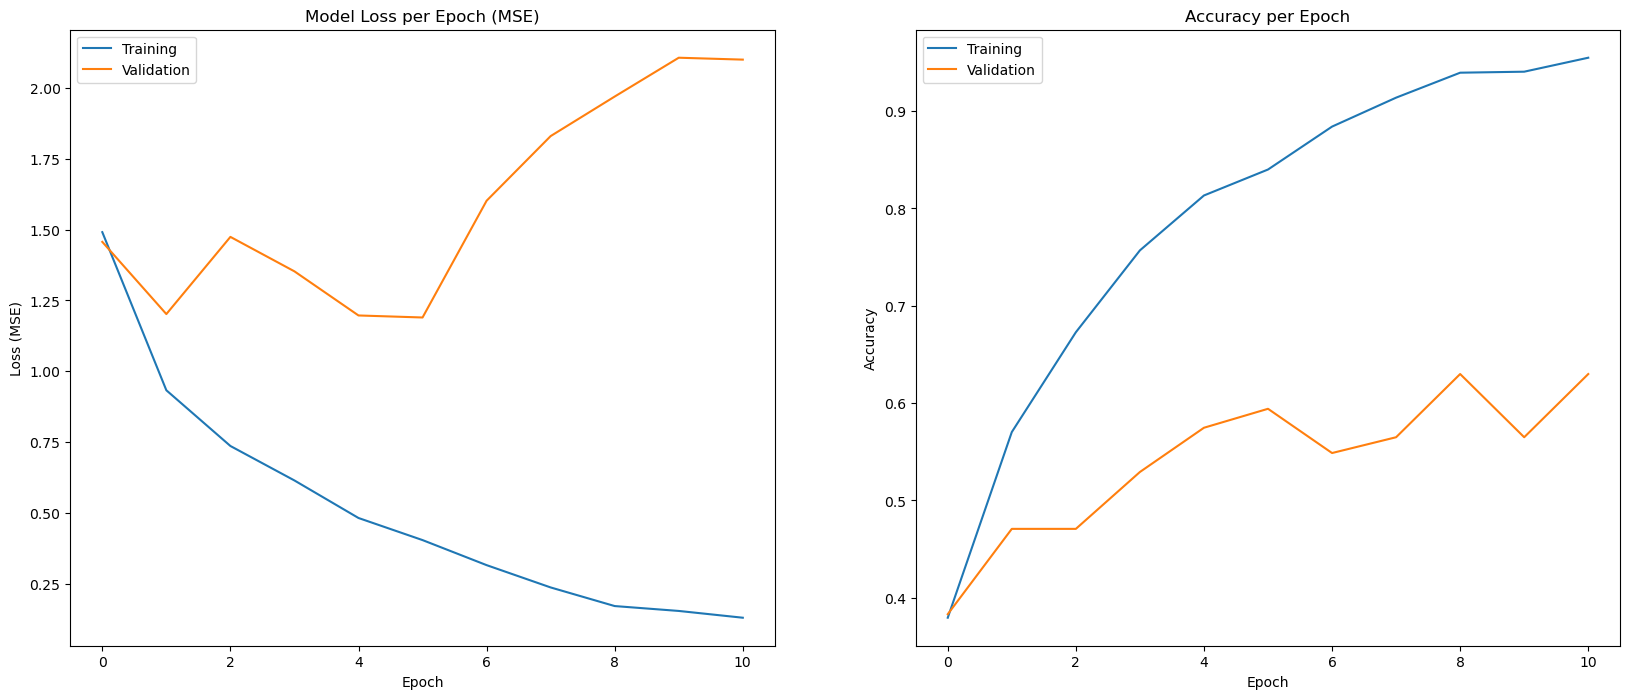

In [54]:
plot_training(model_history)


In [55]:
y_true, y_pred = get_predictions_and_labels(model_multi, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


              precision    recall  f1-score   support

           0       0.73      0.76      0.74        21
           1       0.62      0.71      0.67        21
           2       0.35      0.52      0.42        21
           3       0.91      1.00      0.95        20
           4       1.00      0.20      0.33        20

    accuracy                           0.64       103
   macro avg       0.72      0.64      0.62       103
weighted avg       0.72      0.64      0.62       103



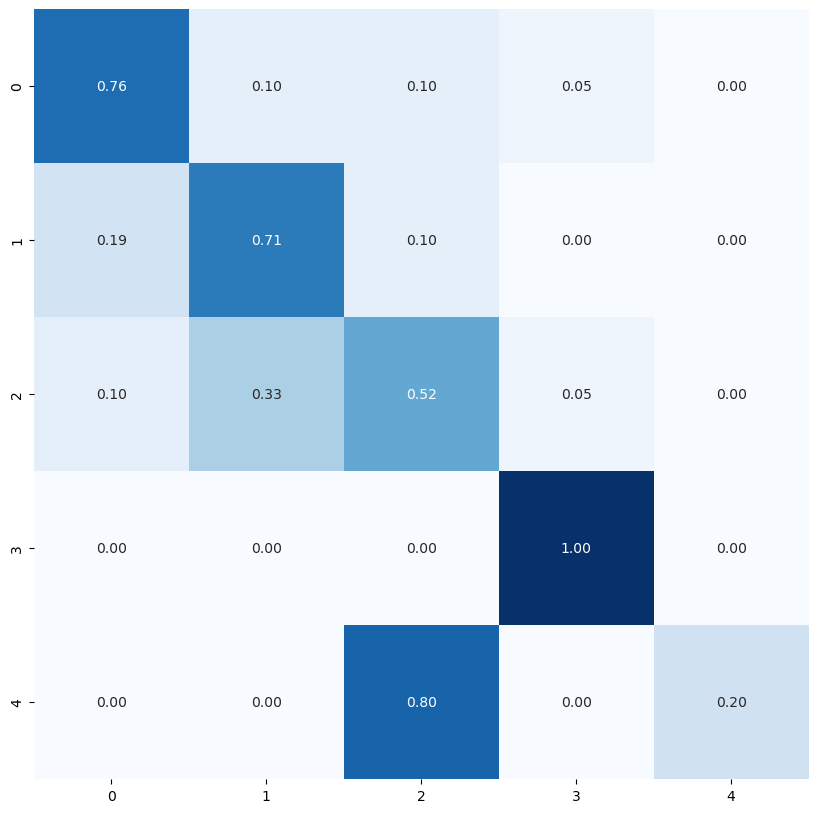

In [56]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


## Binary anomaly classification with pre-split then augmented anomaly images

In [65]:
# Datasets preparation (pre-split)

# Update paths below to run the following cells
# The datasets below can be generated simply by merging all images for each anomaly class from train, validation and test sets used above
# for multi-class classification into a single 'all_anomalies' directory
train_dir = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/split_val_test_before_augmentation/transistor/train'
val_dir = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/split_val_test_before_augmentation/transistor/validation'
holdout_dir = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/split_val_test_before_augmentation/transistor/holdout'

train_ds = image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='binary',
    class_names=['good', 'all_anomalies'],
    seed=42,
    batch_size=16               
)

val_ds = image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='binary',
    class_names=['good', 'all_anomalies'],
    seed=42,
    batch_size=16
)

test_ds = image_dataset_from_directory(
    holdout_dir,
    labels='inferred',
    label_mode='binary',
    class_names=['good', 'all_anomalies'],
    seed=42,
    batch_size=16,
)  


Found 952 files belonging to 2 classes.
Found 302 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [58]:
cats = [p.name for p in Path(train_dir).iterdir() if p.is_dir()]

print('Category to label mapping:')
for label, obj in enumerate(cats):
    print(f'{label}: {obj}')
    

Category to label mapping:
0: good
1: all_anomalies


In [66]:
model_history = model_bin.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,
                          callbacks=[early_stopping]
                         )


Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 481ms/step - accuracy: 0.7248 - loss: 0.9646 - val_accuracy: 0.8013 - val_loss: 0.5184
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 486ms/step - accuracy: 0.8120 - loss: 0.4400 - val_accuracy: 0.9503 - val_loss: 0.2915
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 390ms/step - accuracy: 0.9454 - loss: 0.1457 - val_accuracy: 0.5927 - val_loss: 0.9372
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 388ms/step - accuracy: 0.9758 - loss: 0.0659 - val_accuracy: 0.9768 - val_loss: 0.0624
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 377ms/step - accuracy: 0.9821 - loss: 0.0446 - val_accuracy: 0.9735 - val_loss: 0.0683


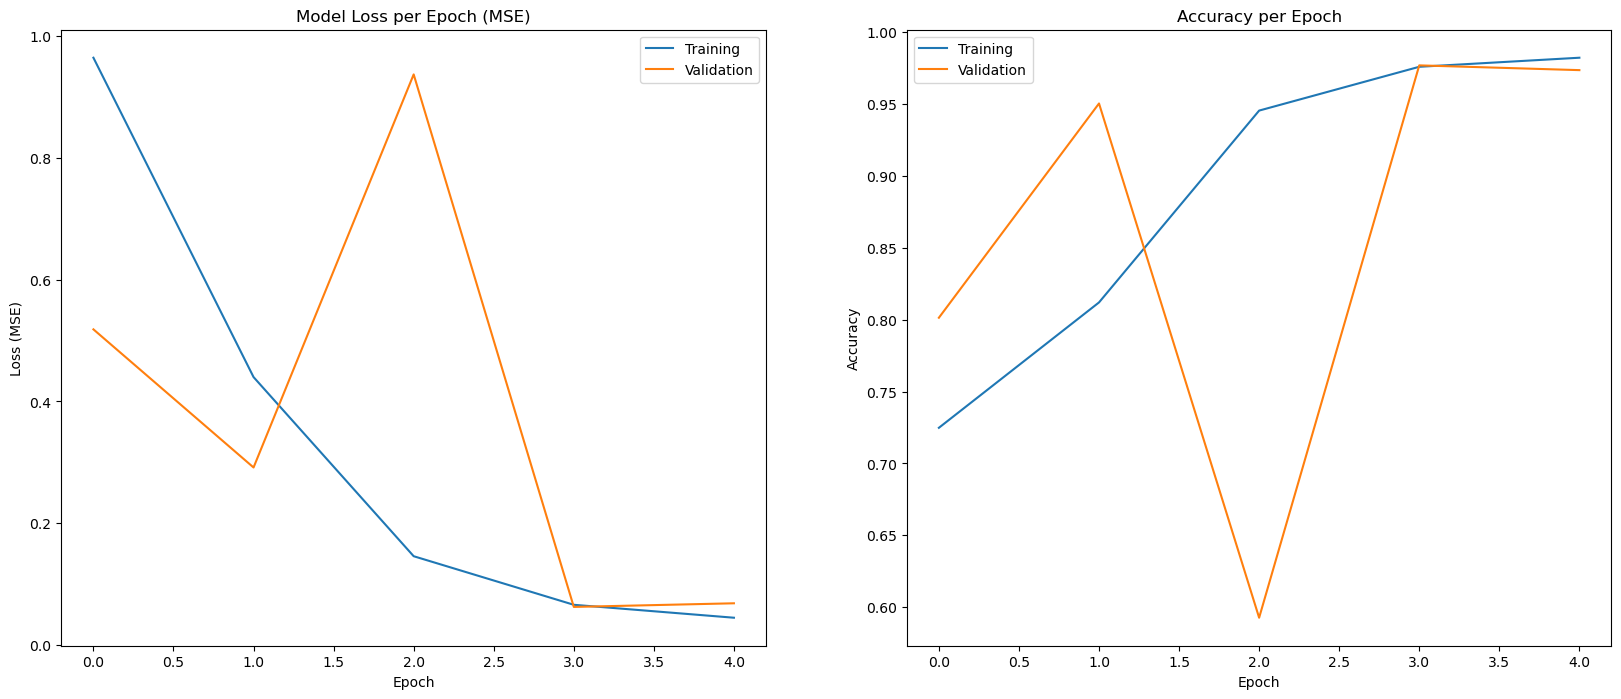

In [67]:
plot_training(model_history)


In [68]:
y_true, y_pred = get_predictions_and_labels(model_bin, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


              precision    recall  f1-score   support

         0.0       0.20      1.00      0.33        20
         1.0       0.00      0.00      0.00        80

    accuracy                           0.20       100
   macro avg       0.10      0.50      0.17       100
weighted avg       0.04      0.20      0.07       100



/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

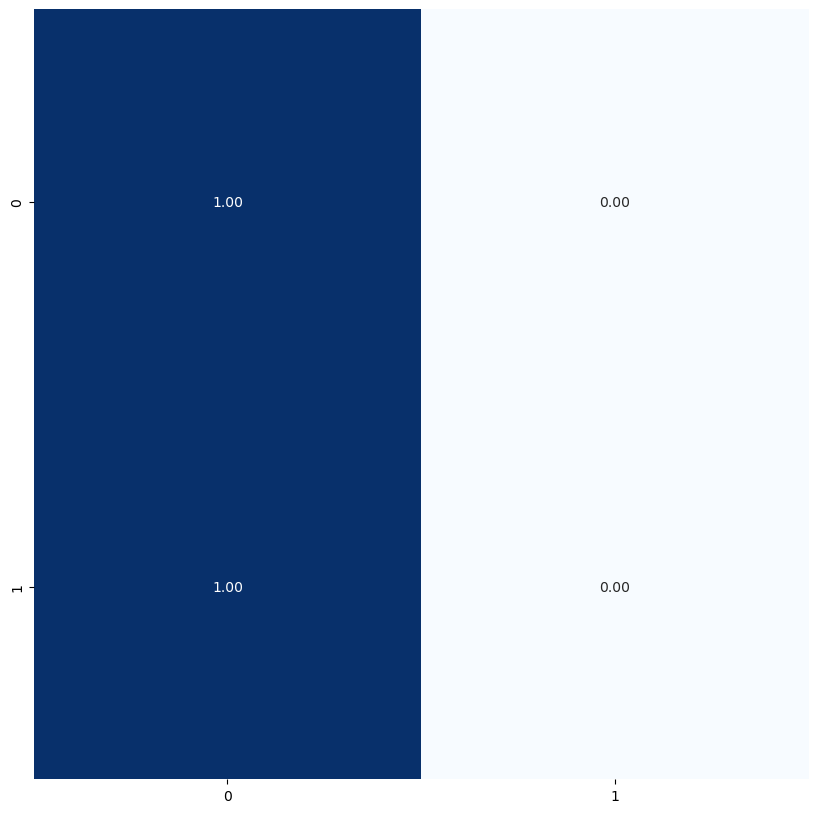

In [78]:
#cm_bin(y_true, y_pred)
#print(y_true)

plot_cm(y_true, y_pred)


## Transfer learning with vgg16 for multi-class anomaly classification

In [11]:
# Imports for using a pre-trained model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D


In [12]:
# Datasets preparation (pre-split)

train_dir = f'{split_aug_data}/transistor/train'
val_dir = f'{split_aug_data}/transistor/validation'
holdout_dir = f'{split_aug_data}/transistor/holdout'

train_ds = image_dataset_from_directory(
    train_dir,
    seed=42,
    batch_size=16,
    image_size=(224, 224)  # Resize images for VGG16
)

val_ds = image_dataset_from_directory(
    val_dir,
    seed=42,
    batch_size=16,
    image_size=(224, 224)  # Resize images for VGG16
)

test_ds = image_dataset_from_directory(
    holdout_dir,
    seed=42,
    batch_size=16,
    image_size=(224, 224)  # Resize images for VGG16
)  


Found 975 files belonging to 5 classes.
Found 308 files belonging to 5 classes.
Found 103 files belonging to 5 classes.


In [13]:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))


In [15]:
# VGG16 model
base_model = VGG16(weights='imagenet', include_top=False)

# Freeze the layers of VGG16
base_model.trainable = False

# Model creation using the Functional API
inputs = Input(shape=(224, 224, 3))

# Apply augmentations
#x = RandomRotation(0.1)(inputs)                          
#x = RandomTranslation(height_factor=0.1, width_factor=0.1)(x) 
#x = RandomZoom(0.1)(x)  
#x = RandomFlip("horizontal")(x)

# Build the model
x = base_model(inputs)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.2)(x)
outputs = Dense(5, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,
                          callbacks=[early_stopping]
                         )


Epoch 1/30


In [ ]:
plot_training(model_history)


In [ ]:
y_true, y_pred = get_predictions_and_labels(model, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


In [ ]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


In [ ]:
# Unfreeze last 4 layers and re-train

for layer in base_model.layers[-4:]:
    layer.trainable = True  

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,
                          callbacks=[early_stopping]
                         )


In [ ]:
plot_training(model_history)


In [ ]:
y_true, y_pred = get_predictions_and_labels(model, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


In [ ]:
# Display the confusion matrix

plot_cm(y_true, y_pred)
